# LOS/NLOS UWB Signal Classification: Feature-Engineered ML vs End-to-End Deep Learning

## Comparative Evaluation

This notebook presents a side-by-side evaluation of two approaches to LOS/NLOS classification on UWB (Ultra-Wideband) channel impulse response (CIR) data:

1. **Feature-Engineered ML Pipeline** — Hand-crafted features (25 dimensions) extracted from the 1016-sample CIR, fed into Logistic Regression, Random Forest, and Gradient Boosted Trees.
2. **End-to-End Deep Learning** — A hybrid 1D-CNN + Transformer model that operates directly on the raw 1016-sample CIR waveform, learning its own features.

**Dataset**: 42,000 UWB measurements (21,000 LOS + 21,000 NLOS) from 7 indoor environments using Decawave DWM1000.

### Key Questions
- Does end-to-end DL outperform hand-crafted feature engineering for CIR classification?
- What trade-offs exist in accuracy, training cost, and interpretability?
- What does the transformer attention reveal about CIR signal structure?

In [1]:
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('inline' if 'get_ipython' in dir() else 'Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, ConfusionMatrixDisplay, f1_score, precision_score, recall_score,
)

from src.data_loader import load_dataset
from src.preprocessing import preprocess, scale_and_split, SCALAR_FEATURES
from src.peak_detection import extract_two_paths
from src.feature_engineering import build_features
from src.classification import train_classifiers
from src.dl_training import train_dl_classifier
from src.dl_models import CIRTransformerClassifier

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = 'white'
sns.set_style('whitegrid')

## 1. Data Loading & Preprocessing

In [2]:
# Load and preprocess
df_raw = load_dataset()
df = preprocess(df_raw)
df_scaled, train_idx, test_idx, scaler = scale_and_split(df)

# Peak detection & feature engineering (for ML pipeline)
path1_idx, path1_amp, path2_idx, path2_amp = extract_two_paths(df)
features_df, labels_cls, labels_range, path_ids = build_features(
    df, path1_idx, path1_amp, path2_idx, path2_amp,
)

# Expanded indices for ML models (84k two-path dataset)
n_orig = len(df)
exp_train_idx = np.concatenate([train_idx, train_idx + n_orig])
exp_test_idx = np.concatenate([test_idx, test_idx + n_orig])

X_train_cls = features_df.iloc[exp_train_idx].values
y_train_cls = labels_cls[exp_train_idx]
X_test_cls = features_df.iloc[exp_test_idx].values
y_test_cls = labels_cls[exp_test_idx]

# DL data: original 42k samples, raw CIR + scalar features
cir_cols = [c for c in df.columns if c.startswith('CIR') and c != 'CIR_PWR']
X_cir_train = df_scaled[cir_cols].values[train_idx]
X_cir_test = df_scaled[cir_cols].values[test_idx]
X_scalar_train = df_scaled[SCALAR_FEATURES].values[train_idx]
X_scalar_test = df_scaled[SCALAR_FEATURES].values[test_idx]
y_dl_train = df_scaled['NLOS'].values[train_idx]
y_dl_test = df_scaled['NLOS'].values[test_idx]

print(f"\nML pipeline: {X_train_cls.shape[0]} train / {X_test_cls.shape[0]} test samples, {X_train_cls.shape[1]} features")
print(f"DL pipeline: {X_cir_train.shape[0]} train / {X_cir_test.shape[0]} test samples, {X_cir_train.shape[1]} CIR + {X_scalar_train.shape[1]} scalar dims")

Loaded dataset: 42000 samples, 1032 columns
  LOS: 21000, NLOS: 21000
  Environments: 7 (ENV_ID 0-6)
Missing values check: 0 missing (dataset is clean)
Removed 4 degenerate samples (RANGE=0 or CIR_PWR=0)
Dropped constant columns: ['CH', 'BITRATE', 'PRFR', 'ENV_ID']
  Note: PREAM_LEN is near-constant (96.3% = 1024.0)
Normalized 1016 CIR columns by RXPACC
Train/test split: 33596 / 8400 (stratified)
StandardScaler fit on training set only (33596 samples)
Peak detection: path2 found in 40862/41996 samples (97.3%)
  1134 samples had no second path detected
Feature engineering: 83992 rows (LOS=20999, NLOS=62993)

ML pipeline: 67192 train / 16800 test samples, 25 features
DL pipeline: 33596 train / 8400 test samples, 1016 CIR + 11 scalar dims


## 2. Approach Overview

### Approach A: Feature-Engineered ML Pipeline

The traditional pipeline extracts **25 hand-crafted features** per path from the CIR:
- **8 per-path features**: path index, amplitude, rise time, decay time, local kurtosis, energy ratio, peak-to-noise ratio, amplitude ratio
- **9 shared scalar features**: FP_AMP1-3, STDEV_NOISE, CIR_PWR, MAX_NOISE, RXPACC, FRAME_LEN, PREAM_LEN
- **1 path indicator**: path_id (1 or 2)

These feed into three classifiers: Logistic Regression, Random Forest (with GridSearchCV), and Gradient Boosted Trees (with GridSearchCV).

The dataset is **expanded to 84,000 samples** via two-path labeling: each original sample produces two rows (path 1 and path 2), with NLOS labels assigned based on propagation physics.

### Approach B: End-to-End CNN+Transformer

The deep learning model operates on the **original 42,000 samples** (no two-path expansion), taking the raw 1016-sample CIR waveform as input:

```
Raw CIR [1016] → 1D-CNN Encoder (3 conv blocks) → [128 channels × 127 timesteps]
    → Positional Encoding → Transformer Encoder (2 layers, 4 heads) → [128 × 127]
    → Global Average Pooling → [128]
    → Concatenate with 11 scalar features → [139]
    → MLP Head → LOS/NLOS prediction
```

The CNN learns local waveform patterns (peak shapes, multipath signatures) while the Transformer captures long-range dependencies across the entire CIR.

### Key Differences

| Aspect | Feature-Engineered ML | CNN+Transformer DL |
|--------|----------------------|-------------------|
| Input dimension | 25 features | 1016 CIR + 11 scalar = 1027 |
| Feature extraction | Manual (domain expertise) | Learned automatically |
| Dataset | 84K (two-path expanded) | 42K (original) |
| Class balance | 25% LOS / 75% NLOS | 50% LOS / 50% NLOS |
| Training | GridSearchCV (CPU) | Adam + early stopping (GPU/MPS) |
| Interpretability | Feature importances | Attention maps |

## 3. Train Both Pipelines

In [3]:
# --- Train ML classifiers (timed) ---
print("=" * 60)
print("Training Feature-Engineered ML Models")
print("=" * 60)
t0 = time.time()
ml_results = train_classifiers(X_train_cls, y_train_cls, X_test_cls, y_test_cls)
ml_time = time.time() - t0
print(f"\nTotal ML training time: {ml_time:.1f}s")

Training Feature-Engineered ML Models

--- Logistic Regression ---
  Accuracy: 0.9185, AUC: 0.9730
              precision    recall  f1-score   support

         LOS       0.77      0.96      0.86      4200
        NLOS       0.99      0.90      0.94     12600

    accuracy                           0.92     16800
   macro avg       0.88      0.93      0.90     16800
weighted avg       0.93      0.92      0.92     16800


--- SVM (RBF) (GridSearchCV, subsampled) ---
  Subsampled to 15000 training samples for SVM
Fitting 5 folds for each of 6 candidates, totalling 30 fits
  Best params: {'svm__C': 10, 'svm__gamma': 'scale'}
  Accuracy: 0.9262, AUC: 0.9735
              precision    recall  f1-score   support

         LOS       0.79      0.97      0.87      4200
        NLOS       0.99      0.91      0.95     12600

    accuracy                           0.93     16800
   macro avg       0.89      0.94      0.91     16800
weighted avg       0.94      0.93      0.93     16800


--- Rand

In [27]:
# --- Train DL model (timed) ---
print("=" * 60)
print("Training CNN+Transformer on Raw CIR")
print("=" * 60)
t0 = time.time()
dl_result = train_dl_classifier(
    X_cir_train, X_scalar_train, y_dl_train,
    X_cir_test, X_scalar_test, y_dl_test,
)
dl_time = time.time() - t0
print(f"\nDL training time: {dl_time:.1f}s")

Training CNN+Transformer on Raw CIR

--- CNN+Transformer (device: cuda) ---
  Epoch   1: train_loss=0.3865, val_loss=0.3288
  Epoch   5: train_loss=0.2962, val_loss=0.2311
  Epoch  10: train_loss=0.2528, val_loss=0.1962
  Epoch  15: train_loss=0.2292, val_loss=0.1866
  Epoch  20: train_loss=0.2144, val_loss=0.1907
  Epoch  25: train_loss=0.1809, val_loss=0.1801
  Early stopping at epoch 29
  Accuracy: 0.9332, AUC: 0.9796
              precision    recall  f1-score   support

         LOS       0.93      0.93      0.93      4200
        NLOS       0.93      0.93      0.93      4200

    accuracy                           0.93      8400
   macro avg       0.93      0.93      0.93      8400
weighted avg       0.93      0.93      0.93      8400


DL training time: 297.7s


## 4. Results Comparison

### 4.1 Summary Table

> **Important note on evaluation context**: The ML models are evaluated on the **two-path expanded** test set (16,800 samples, 25%/75% LOS/NLOS split), while the DL model is evaluated on the **original** test set (8,400 samples, 50/50 balanced). This difference in class distribution and dataset construction is itself a key finding — the DL model achieves competitive performance on a balanced, harder classification task without requiring domain-specific two-path expansion.

In [5]:
# Build comparison table
all_results = {**ml_results, 'CNN+Transformer': dl_result}

rows = []
for name, res in all_results.items():
    y_true = y_test_cls if name != 'CNN+Transformer' else y_dl_test
    y_pred = res['y_pred']
    rows.append({
        'Model': name,
        'Approach': 'Feature-Engineered ML' if name != 'CNN+Transformer' else 'End-to-End DL',
        'Accuracy': res['accuracy'],
        'AUC': res['auc'],
        'Precision (LOS)': precision_score(y_true, y_pred, pos_label=0),
        'Recall (LOS)': recall_score(y_true, y_pred, pos_label=0),
        'F1 (LOS)': f1_score(y_true, y_pred, pos_label=0),
        'Precision (NLOS)': precision_score(y_true, y_pred, pos_label=1),
        'Recall (NLOS)': recall_score(y_true, y_pred, pos_label=1),
        'F1 (NLOS)': f1_score(y_true, y_pred, pos_label=1),
        'F1 (macro)': f1_score(y_true, y_pred, average='macro'),
        'Test Samples': len(y_true),
    })

summary_df = pd.DataFrame(rows).set_index('Model')
summary_df.style.format({
    'Accuracy': '{:.4f}', 'AUC': '{:.4f}',
    'Precision (LOS)': '{:.4f}', 'Recall (LOS)': '{:.4f}', 'F1 (LOS)': '{:.4f}',
    'Precision (NLOS)': '{:.4f}', 'Recall (NLOS)': '{:.4f}', 'F1 (NLOS)': '{:.4f}',
    'F1 (macro)': '{:.4f}', 'Test Samples': '{:,}',
}).background_gradient(subset=['Accuracy', 'AUC', 'F1 (macro)'], cmap='Greens')

,Approach,Accuracy,AUC,Precision (LOS),Recall (LOS),F1 (LOS),Precision (NLOS),Recall (NLOS),F1 (NLOS),F1 (macro),Test Samples
Model,,,,,,,,,,,
Logistic Regression,Feature-Engineered ML,0.9185,0.9730,0.7686,0.9640,0.8553,0.9869,0.9033,0.9432,0.8993,"16,800"
SVM (RBF),Feature-Engineered ML,0.9262,0.9735,0.7868,0.9667,0.8675,0.9880,0.9127,0.9488,0.9082,"16,800"
Random Forest,Feature-Engineered ML,0.9396,0.9821,0.8398,0.9374,0.8859,0.9783,0.9404,0.9590,0.9224,"16,800"
Gradient Boosted Trees,Feature-Engineered ML,0.9312,0.9821,0.7988,0.9688,0.8756,0.9888,0.9187,0.9524,0.9140,"16,800"
XGBoost,Feature-Engineered ML,0.9398,0.9832,0.8401,0.9379,0.8863,0.9784,0.9405,0.9591,0.9227,"16,800"
CNN+Transformer,End-to-End DL,0.9351,0.9825,0.9315,0.9393,0.9354,0.9388,0.9310,0.9348,0.9351,"8,400"


### 4.2 ROC Curves

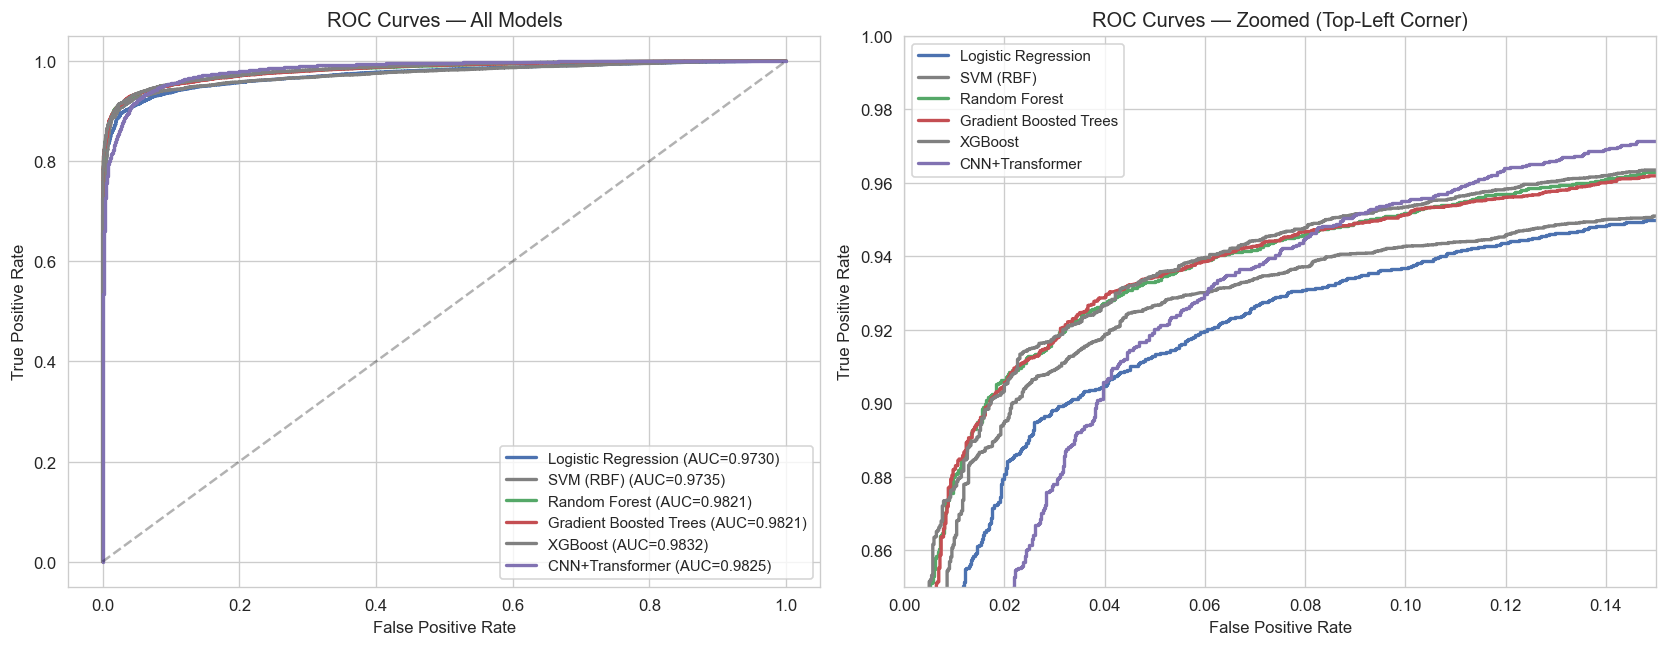

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: all models overlaid
ax = axes[0]
colors = {'Logistic Regression': '#4c72b0', 'Random Forest': '#55a868',
          'Gradient Boosted Trees': '#c44e52', 'CNN+Transformer': '#8172b2'}
for name, res in all_results.items():
    ax.plot(res['fpr'], res['tpr'], label=f"{name} (AUC={res['auc']:.4f})",
            color=colors.get(name, 'gray'), linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(fontsize=9)

# Right: zoomed into top-left corner
ax2 = axes[1]
for name, res in all_results.items():
    ax2.plot(res['fpr'], res['tpr'], label=f"{name}",
             color=colors.get(name, 'gray'), linewidth=2)
ax2.set_xlim(0, 0.15)
ax2.set_ylim(0.85, 1.0)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves — Zoomed (Top-Left Corner)')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

### 4.3 Confusion Matrices

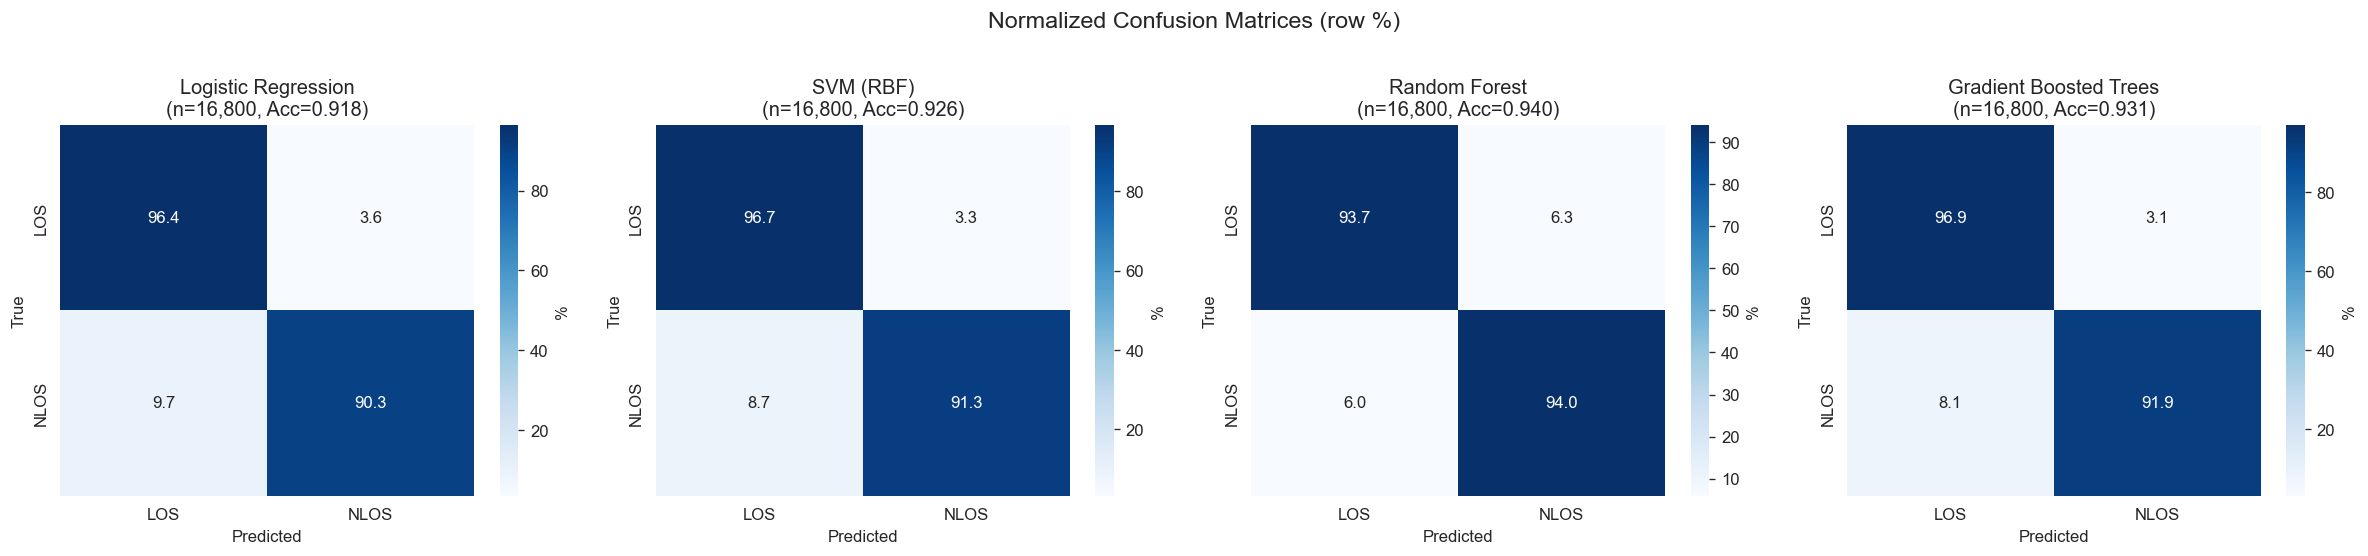

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, (name, res) in zip(axes, all_results.items()):
    cm = res['confusion_matrix']
    # Normalize to percentages for fair comparison across different test set sizes
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues', ax=ax,
                xticklabels=['LOS', 'NLOS'], yticklabels=['LOS', 'NLOS'],
                cbar_kws={'label': '%'})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    n_test = cm.sum()
    ax.set_title(f'{name}\n(n={n_test:,}, Acc={res["accuracy"]:.3f})')

fig.suptitle('Normalized Confusion Matrices (row %)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.4 Per-Class Performance Comparison

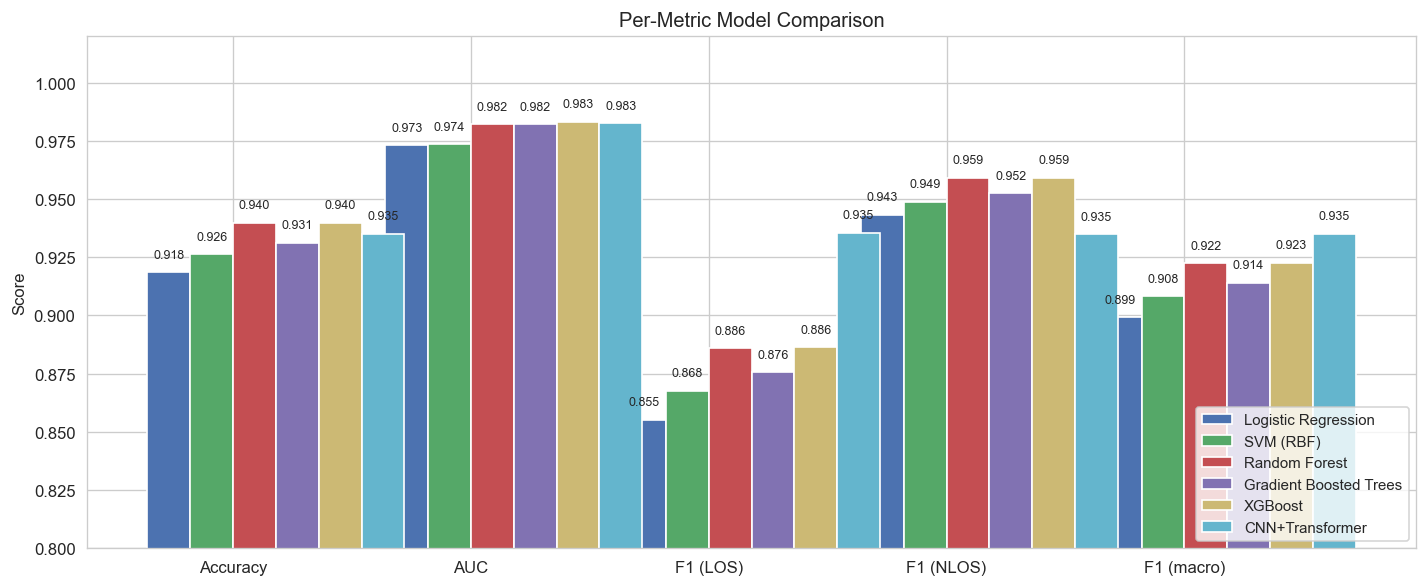

In [29]:
metrics = ['Accuracy', 'AUC', 'F1 (LOS)', 'F1 (NLOS)', 'F1 (macro)']
models = list(all_results.keys())

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics))
width = 0.18
colors_bar = ['#4c72b0', '#55a868', '#c44e52', '#8172b2', '#ccb974', '#64b5cd', '#e377c2', '#7f7f7f'][:len(models)]

for i, model in enumerate(models):
    vals = [summary_df.loc[model, m] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=colors_bar[i])
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0.8, 1.02)
ax.set_ylabel('Score')
ax.set_title('Per-Metric Model Comparison')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 4.5 Training Time Comparison

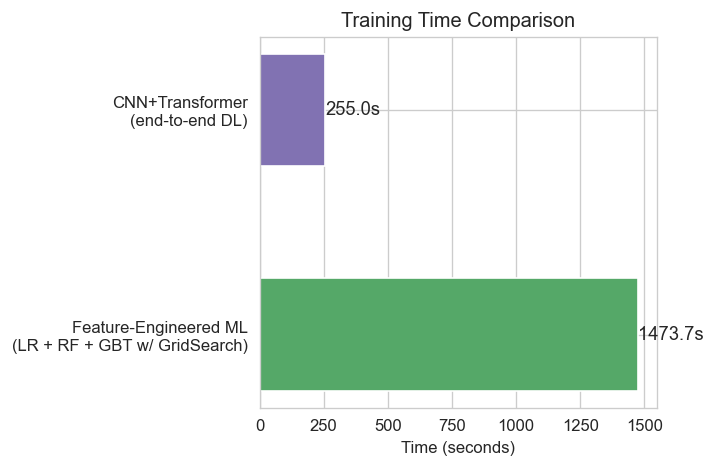

ML pipeline total: 1473.7s (includes GridSearchCV for RF and GBT)
DL pipeline total: 255.0s (Adam + early stopping)


In [21]:
time_df = pd.DataFrame({
    'Pipeline': ['Feature-Engineered ML\n(LR + RF + GBT w/ GridSearch)', 'CNN+Transformer\n(end-to-end DL)'],
    'Training Time (s)': [ml_time, dl_time],
})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.barh(time_df['Pipeline'], time_df['Training Time (s)'],
               color=['#55a868', '#8172b2'], height=0.5)
for bar, t in zip(bars, time_df['Training Time (s)']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f'{t:.1f}s', va='center', fontsize=11)
ax.set_xlabel('Time (seconds)')
ax.set_title('Training Time Comparison')
plt.tight_layout()
plt.show()

print(f"ML pipeline total: {ml_time:.1f}s (includes GridSearchCV for RF and GBT)")
print(f"DL pipeline total: {dl_time:.1f}s (Adam + early stopping)")

## 5. Interpretability Analysis

### 5.1 ML: Feature Importances (Random Forest)

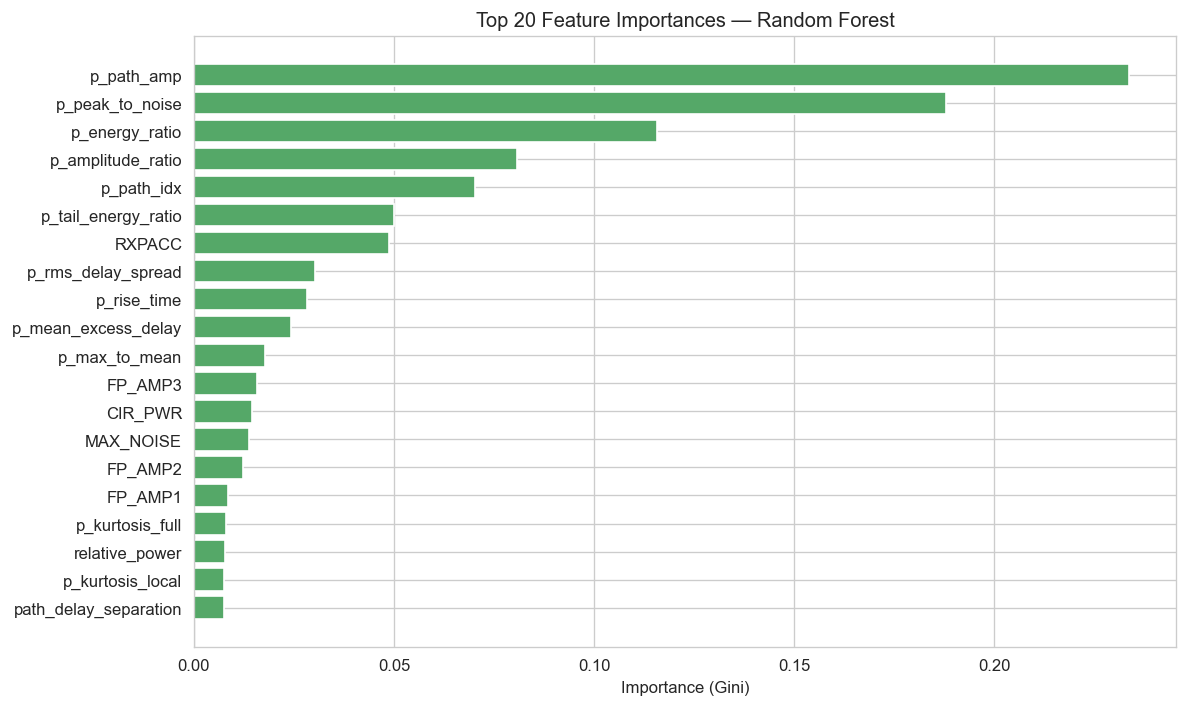


Top 10 features:
   1. p_path_amp                0.2338
   2. p_peak_to_noise           0.1880
   3. p_energy_ratio            0.1158
   4. p_amplitude_ratio         0.0808
   5. p_path_idx                0.0704
   6. p_tail_energy_ratio       0.0499
   7. RXPACC                    0.0487
   8. p_rms_delay_spread        0.0301
   9. p_rise_time               0.0282
  10. p_mean_excess_delay       0.0242


In [22]:
feature_names = list(features_df.columns)
importances = ml_results['Random Forest']['feature_importances']
top_n = min(20, len(importances))
idx = np.argsort(importances)[::-1][:top_n]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(range(top_n), importances[idx[::-1]], color='#55a868')
ax.set_yticks(range(top_n))
ax.set_yticklabels([feature_names[i] for i in idx[::-1]])
ax.set_xlabel('Importance (Gini)')
ax.set_title(f'Top {top_n} Feature Importances — Random Forest')
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
for rank, i in enumerate(idx[:10], 1):
    print(f"  {rank:2d}. {feature_names[i]:25s} {importances[i]:.4f}")

### 5.2 DL: Transformer Attention Maps

The transformer's self-attention mechanism reveals which regions of the CIR waveform (after CNN encoding) the model focuses on when making LOS/NLOS decisions. Below we visualize attention weights upsampled back to the original CIR resolution for sample LOS and NLOS waveforms.

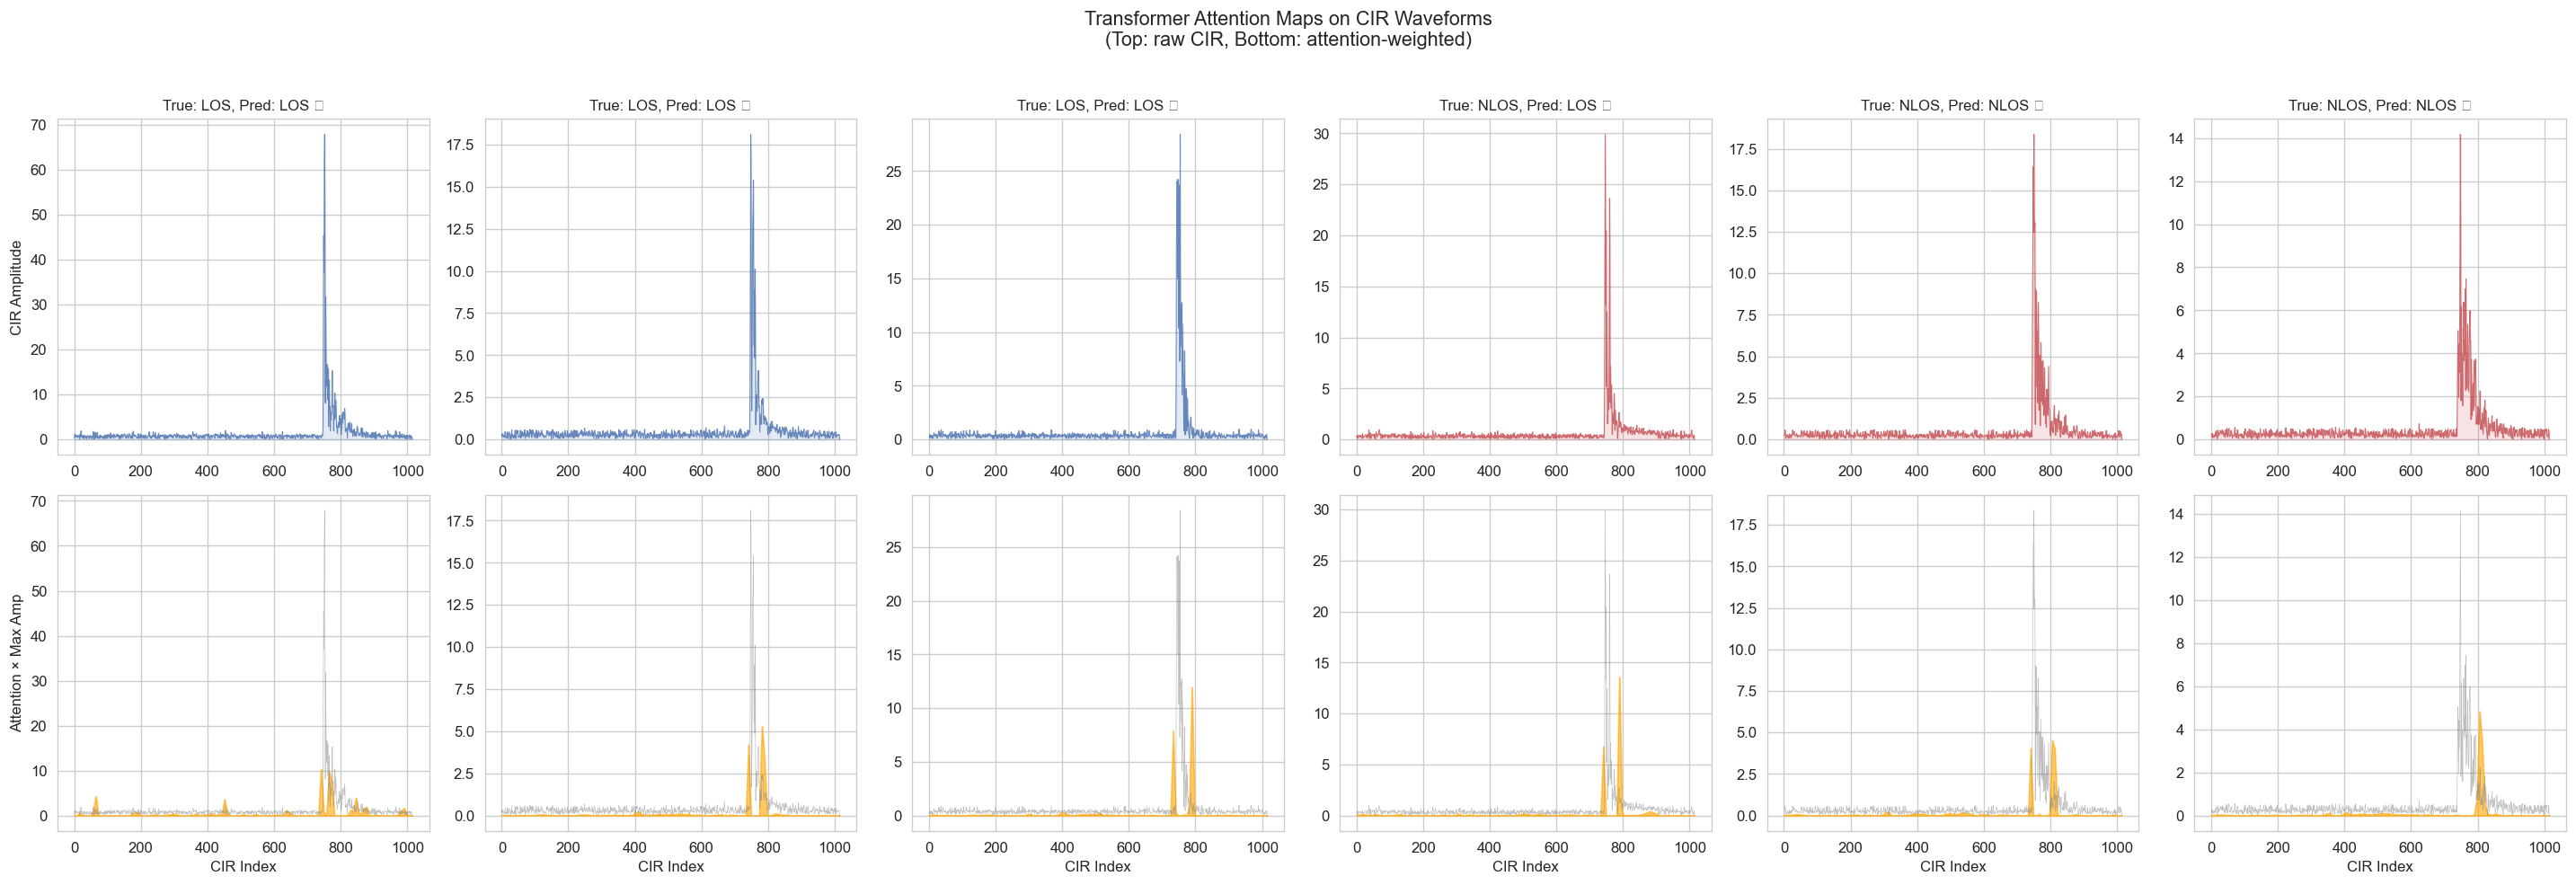

In [23]:
dl_model = dl_result['model']
device = next(dl_model.parameters()).device
dl_model.eval()

# Pick 3 LOS and 3 NLOS from test set
test_labels = df_scaled['NLOS'].values[test_idx]
los_samples = test_idx[test_labels == 0][:3]
nlos_samples = test_idx[test_labels == 1][:3]
sample_idxs = np.concatenate([los_samples, nlos_samples])
sample_labels = ['LOS'] * 3 + ['NLOS'] * 3

fig, axes = plt.subplots(2, 6, figsize=(24, 8))

for col, (idx, true_label) in enumerate(zip(sample_idxs, sample_labels)):
    cir_raw = df_scaled.iloc[idx][cir_cols].values.astype(float)
    cir_tensor = torch.tensor(cir_raw, dtype=torch.float32).unsqueeze(0).to(device)
    scalar_tensor = torch.tensor(
        df_scaled.iloc[idx][SCALAR_FEATURES].values.astype(float),
        dtype=torch.float32,
    ).unsqueeze(0).to(device)

    with torch.no_grad():
        logit = dl_model(cir_tensor, scalar_tensor)
        pred = 'NLOS' if logit.item() > 0 else 'LOS'

    # Get attention: [1, seq_len, seq_len] -> average over queries -> [seq_len]
    attn = dl_model.last_attention_weights
    if attn is not None:
        attn_avg = attn[0].mean(dim=0).cpu().numpy()
        attn_up = np.interp(np.linspace(0, 1, len(cir_raw)),
                            np.linspace(0, 1, len(attn_avg)), attn_avg)
    else:
        attn_up = np.zeros(len(cir_raw))

    # Top row: CIR waveform
    ax_top = axes[0, col]
    color = '#4c72b0' if true_label == 'LOS' else '#c44e52'
    ax_top.plot(cir_raw, color=color, linewidth=0.6, alpha=0.8)
    ax_top.fill_between(range(len(cir_raw)), 0, cir_raw, alpha=0.15, color=color)
    correct = '✓' if pred == true_label else '✗'
    ax_top.set_title(f'True: {true_label}, Pred: {pred} {correct}', fontsize=10)
    if col == 0:
        ax_top.set_ylabel('CIR Amplitude')

    # Bottom row: attention overlay
    ax_bot = axes[1, col]
    ax_bot.plot(cir_raw, color='gray', linewidth=0.4, alpha=0.5)
    ax_bot.fill_between(range(len(cir_raw)), 0, attn_up * cir_raw.max(),
                        alpha=0.6, color='orange')
    ax_bot.set_xlabel('CIR Index')
    if col == 0:
        ax_bot.set_ylabel('Attention × Max Amp')

fig.suptitle('Transformer Attention Maps on CIR Waveforms\n(Top: raw CIR, Bottom: attention-weighted)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 DL: CNN Feature Map Visualization

We can also visualize what the CNN encoder has learned by examining its intermediate feature maps for LOS vs NLOS inputs.

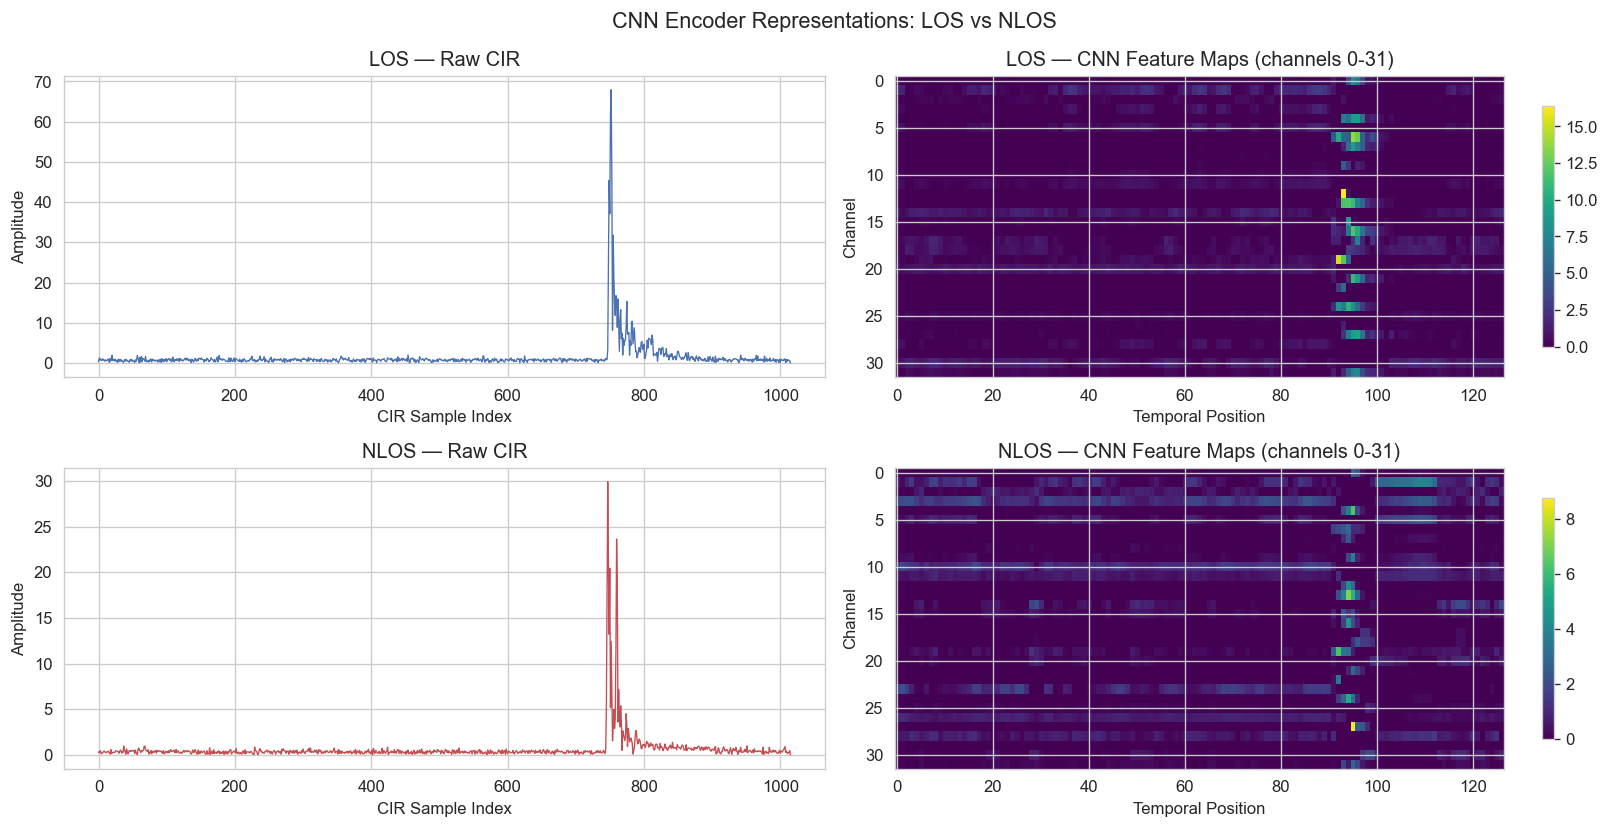

In [24]:
# Visualize CNN encoder output for a LOS vs NLOS sample
fig, axes = plt.subplots(2, 2, figsize=(14, 7))

for row, (idx, label) in enumerate([(los_samples[0], 'LOS'), (nlos_samples[0], 'NLOS')]):
    cir_raw = df_scaled.iloc[idx][cir_cols].values.astype(float)
    cir_tensor = torch.tensor(cir_raw, dtype=torch.float32).unsqueeze(0).to(device)  # [1, 1016]

    with torch.no_grad():
        x = cir_tensor.unsqueeze(1)          # [1, 1, 1016]
        x = dl_model.multi_scale(x)          # [1, 32, 1016]
        x = dl_model.pool1(x)                # [1, 32, 508]
        x = dl_model.res_block2(x)           # [1, 64, 254]
        cnn_out = dl_model.res_block3(x)     # [1, 128, 127]

    cnn_features = cnn_out[0].cpu().numpy()  # [128, 127]

    # Left: raw CIR
    axes[row, 0].plot(cir_raw, color='#4c72b0' if label == 'LOS' else '#c44e52', linewidth=0.8)
    axes[row, 0].set_title(f'{label} — Raw CIR')
    axes[row, 0].set_xlabel('CIR Sample Index')
    axes[row, 0].set_ylabel('Amplitude')

    # Right: CNN feature map heatmap (first 32 channels)
    im = axes[row, 1].imshow(cnn_features[:32], aspect='auto', cmap='viridis',
                              interpolation='nearest')
    axes[row, 1].set_title(f'{label} — CNN Feature Maps (channels 0-31)')
    axes[row, 1].set_xlabel('Temporal Position')
    axes[row, 1].set_ylabel('Channel')
    plt.colorbar(im, ax=axes[row, 1], shrink=0.8)

fig.suptitle('CNN Encoder Representations: LOS vs NLOS', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Error Analysis

### 6.1 Prediction Confidence Distribution

Examining the distribution of prediction probabilities reveals how confident each model is in its decisions.

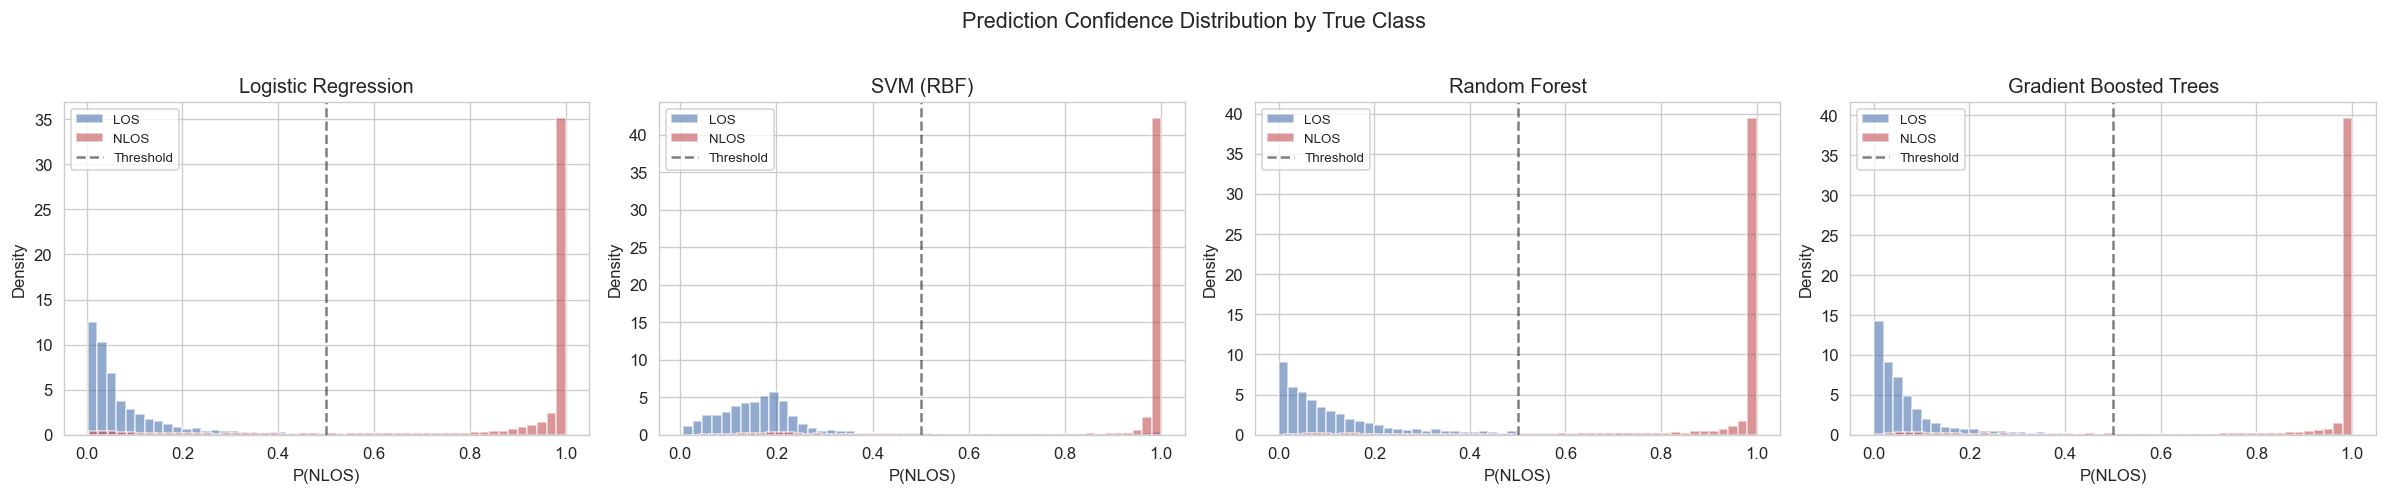

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, res) in zip(axes, all_results.items()):
    y_true = y_test_cls if name != 'CNN+Transformer' else y_dl_test
    probs = res['y_prob']

    ax.hist(probs[y_true == 0], bins=50, alpha=0.6, color='#4c72b0', label='LOS', density=True)
    ax.hist(probs[y_true == 1], bins=50, alpha=0.6, color='#c44e52', label='NLOS', density=True)
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.5, label='Threshold')
    ax.set_xlabel('P(NLOS)')
    ax.set_ylabel('Density')
    ax.set_title(name)
    ax.legend(fontsize=8)

fig.suptitle('Prediction Confidence Distribution by True Class', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.2 Misclassified Sample Analysis (CNN+Transformer)

Let's examine where the DL model fails — are there patterns in the misclassified CIR waveforms?

Total misclassified: 545 / 8400 (6.5%)
  False Positives (LOS predicted as NLOS): 255
  False Negatives (NLOS predicted as LOS): 290


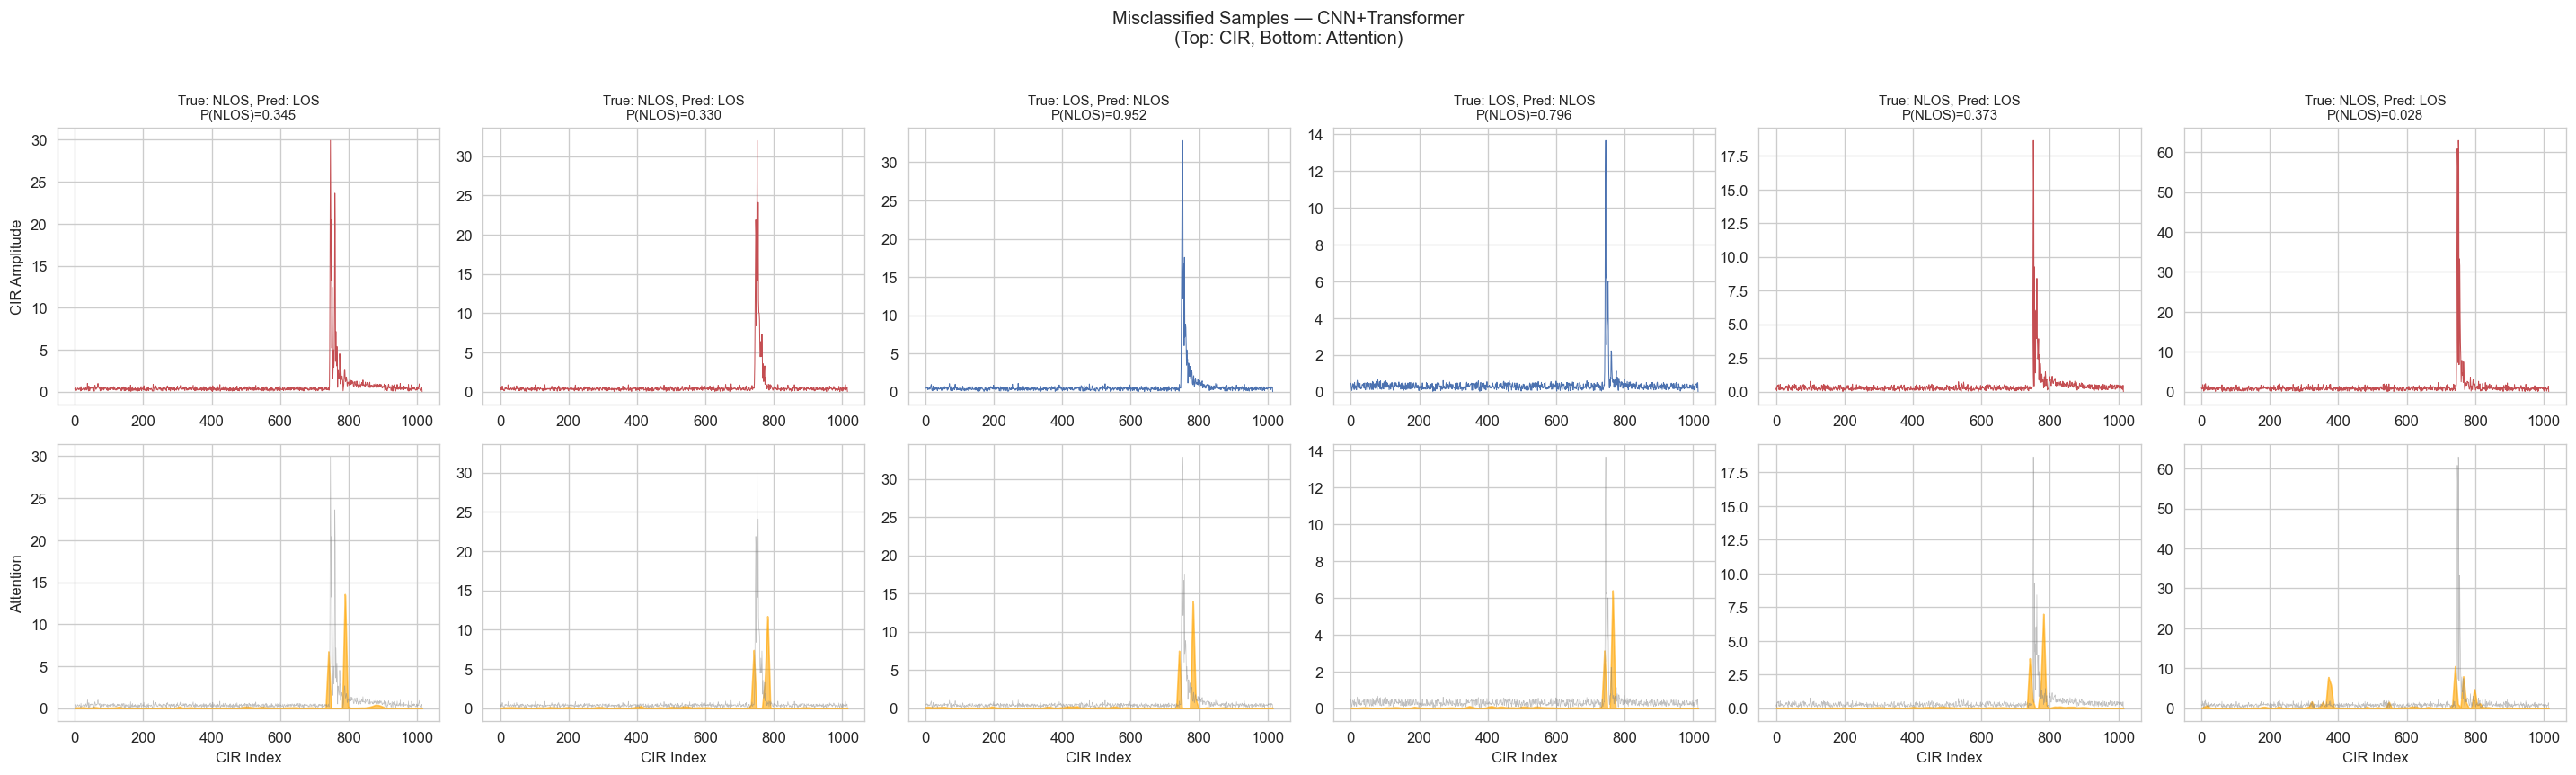

In [14]:
# Find misclassified samples
dl_pred = dl_result['y_pred']
dl_prob = dl_result['y_prob']
misclassified = test_idx[dl_pred != y_dl_test]
mis_true = y_dl_test[dl_pred != y_dl_test]
mis_prob = dl_prob[dl_pred != y_dl_test]

print(f"Total misclassified: {len(misclassified)} / {len(y_dl_test)} ({100*len(misclassified)/len(y_dl_test):.1f}%)")
print(f"  False Positives (LOS predicted as NLOS): {((mis_true == 0)).sum()}")
print(f"  False Negatives (NLOS predicted as LOS): {((mis_true == 1)).sum()}")

# Plot some misclassified examples
n_show = min(6, len(misclassified))
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 7))

for col in range(n_show):
    idx = misclassified[col]
    cir_raw = df_scaled.iloc[idx][cir_cols].values.astype(float)
    true = 'NLOS' if y_dl_test[dl_pred != y_dl_test][col] == 1 else 'LOS'
    pred = 'NLOS' if dl_pred[dl_pred != y_dl_test][col] == 1 else 'LOS'
    prob = mis_prob[col]

    # CIR waveform
    color = '#c44e52' if true == 'NLOS' else '#4c72b0'
    axes[0, col].plot(cir_raw, color=color, linewidth=0.6)
    axes[0, col].set_title(f'True: {true}, Pred: {pred}\nP(NLOS)={prob:.3f}', fontsize=9)
    if col == 0:
        axes[0, col].set_ylabel('CIR Amplitude')

    # Attention for this sample
    cir_tensor = torch.tensor(cir_raw, dtype=torch.float32).unsqueeze(0).to(device)
    scalar_tensor = torch.tensor(
        df_scaled.iloc[idx][SCALAR_FEATURES].values.astype(float),
        dtype=torch.float32,
    ).unsqueeze(0).to(device)
    with torch.no_grad():
        dl_model(cir_tensor, scalar_tensor)
    attn = dl_model.last_attention_weights
    if attn is not None:
        attn_avg = attn[0].mean(dim=0).cpu().numpy()
        attn_up = np.interp(np.linspace(0, 1, len(cir_raw)),
                            np.linspace(0, 1, len(attn_avg)), attn_avg)
    else:
        attn_up = np.zeros(len(cir_raw))

    axes[1, col].plot(cir_raw, color='gray', linewidth=0.4, alpha=0.5)
    axes[1, col].fill_between(range(len(cir_raw)), 0, attn_up * cir_raw.max(),
                               alpha=0.6, color='orange')
    axes[1, col].set_xlabel('CIR Index')
    if col == 0:
        axes[1, col].set_ylabel('Attention')

fig.suptitle('Misclassified Samples — CNN+Transformer\n(Top: CIR, Bottom: Attention)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 6.3 Error Rate by Signal Characteristics

Do models struggle more at certain ranges or noise levels?

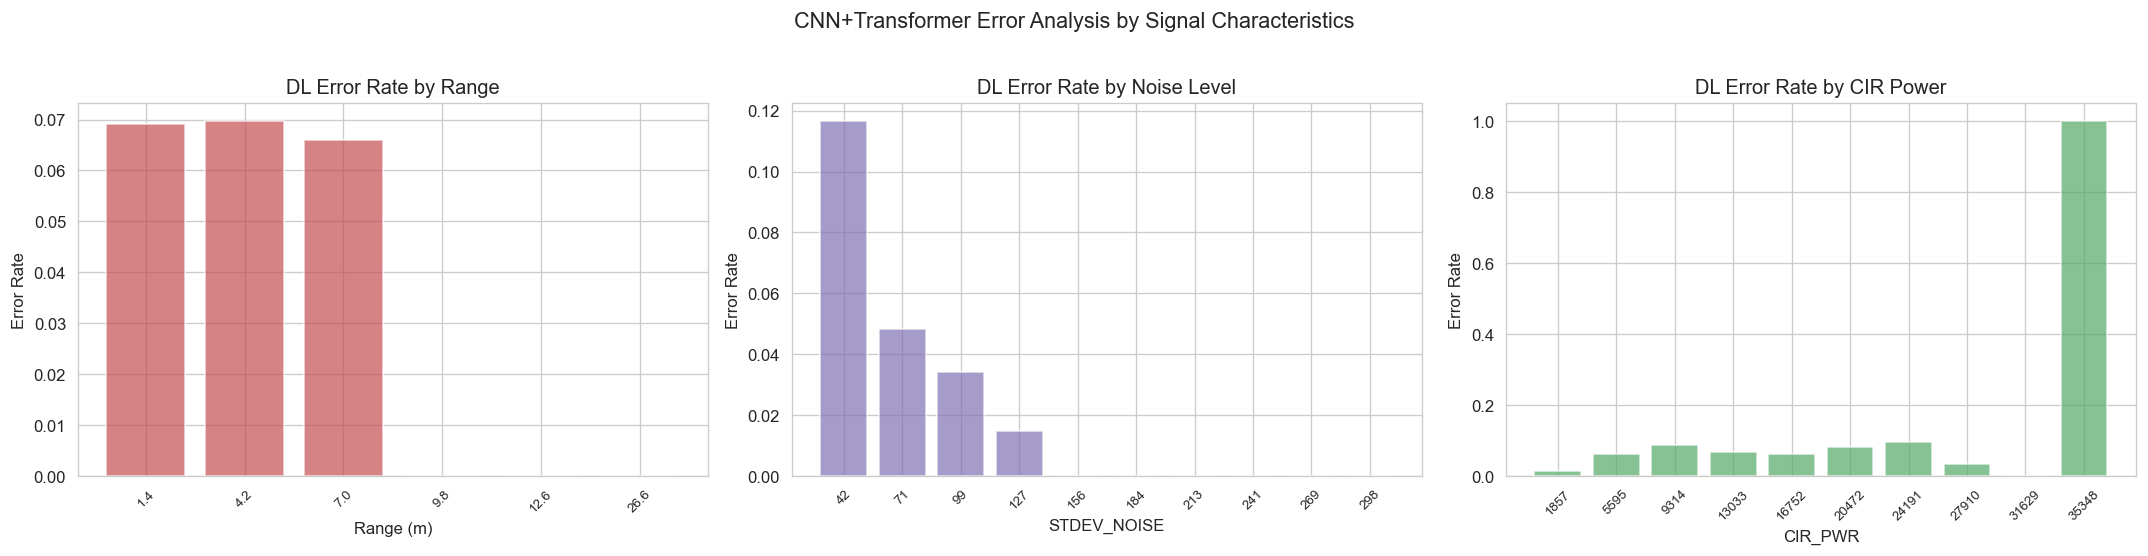

In [15]:
# Analyze DL errors by RANGE and STDEV_NOISE
test_df = df.iloc[test_idx].copy()
test_df['correct'] = (dl_pred == y_dl_test).astype(int)
test_df['true_label'] = y_dl_test

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

# Error rate by range bins
test_df['range_bin'] = pd.cut(test_df['RANGE'], bins=10)
err_by_range = test_df.groupby('range_bin', observed=True)['correct'].agg(['mean', 'count'])
ax = axes[0]
ax.bar(range(len(err_by_range)), 1 - err_by_range['mean'], color='#c44e52', alpha=0.7)
ax.set_xticks(range(len(err_by_range)))
ax.set_xticklabels([f'{iv.mid:.1f}' for iv in err_by_range.index], rotation=45, fontsize=8)
ax.set_xlabel('Range (m)')
ax.set_ylabel('Error Rate')
ax.set_title('DL Error Rate by Range')

# Error rate by noise bins
test_df['noise_bin'] = pd.cut(test_df['STDEV_NOISE'], bins=10)
err_by_noise = test_df.groupby('noise_bin', observed=True)['correct'].agg(['mean', 'count'])
ax = axes[1]
ax.bar(range(len(err_by_noise)), 1 - err_by_noise['mean'], color='#8172b2', alpha=0.7)
ax.set_xticks(range(len(err_by_noise)))
ax.set_xticklabels([f'{iv.mid:.0f}' for iv in err_by_noise.index], rotation=45, fontsize=8)
ax.set_xlabel('STDEV_NOISE')
ax.set_ylabel('Error Rate')
ax.set_title('DL Error Rate by Noise Level')

# Error rate by CIR power bins
test_df['pwr_bin'] = pd.cut(test_df['CIR_PWR'], bins=10)
err_by_pwr = test_df.groupby('pwr_bin', observed=True)['correct'].agg(['mean', 'count'])
ax = axes[2]
ax.bar(range(len(err_by_pwr)), 1 - err_by_pwr['mean'], color='#55a868', alpha=0.7)
ax.set_xticks(range(len(err_by_pwr)))
ax.set_xticklabels([f'{iv.mid:.0f}' for iv in err_by_pwr.index], rotation=45, fontsize=8)
ax.set_xlabel('CIR_PWR')
ax.set_ylabel('Error Rate')
ax.set_title('DL Error Rate by CIR Power')

fig.suptitle('CNN+Transformer Error Analysis by Signal Characteristics', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 7. Model Complexity Comparison

In [30]:
# Model parameter counts
dl_params = sum(p.numel() for p in dl_model.parameters())
dl_trainable = sum(p.numel() for p in dl_model.parameters() if p.requires_grad)

rf_model = ml_results['Random Forest']['model']
# Approximate RF complexity: n_estimators * n_nodes * features
rf_estimators = rf_model.n_estimators
rf_total_nodes = sum(est.tree_.node_count for est in rf_model.estimators_)

gbt_model = ml_results['Gradient Boosted Trees']['model']
gbt_estimators = gbt_model.n_iter_  # HistGBT uses n_iter_, not n_estimators
try:
    gbt_total_nodes = sum(
        predictor.get_n_leaf_nodes()
        for predictor_list in gbt_model._predictors
        for predictor in predictor_list
    )
except Exception:
    gbt_total_nodes = gbt_estimators * 50  # approximate

complexity_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Gradient Boosted Trees', 'CNN+Transformer'],
    'Type': ['Linear', 'Ensemble (bagging)', 'Ensemble (boosting)', 'Neural Network'],
    'Parameters / Nodes': [
        f'{X_train_cls.shape[1] + 1:,} weights',
        f'{rf_total_nodes:,} nodes ({rf_estimators} trees)',
        f'{gbt_total_nodes:,} nodes ({gbt_estimators} trees)',
        f'{dl_params:,} parameters',
    ],
    'Input Dim': [25, 25, 25, 1027],
    'Feature Eng. Required': ['Yes (25 features)', 'Yes (25 features)', 'Yes (25 features)', 'No (raw CIR)'],
    'Hardware': ['CPU', 'CPU (parallel)', 'CPU', 'GPU/MPS preferred'],
}

complexity_df = pd.DataFrame(complexity_data).set_index('Model')
complexity_df

,Type,Parameters / Nodes,Input Dim,Feature Eng. Required,Hardware
Model,,,,,
Logistic Regression,Linear,26 weights,25,Yes (25 features),CPU
Random Forest,Ensemble (bagging),"1,979,342 nodes (500 trees)",25,Yes (25 features),CPU (parallel)
Gradient Boosted Trees,Ensemble (boosting),"6,189 nodes (200 trees)",25,Yes (25 features),CPU
CNN+Transformer,Neural Network,"390,393 parameters",1027,No (raw CIR),GPU/MPS preferred


## 8. DL Model Architecture Details

In [31]:
print("CNN+Transformer Architecture:")
print("=" * 60)
print(dl_model)
print(f"\nTotal parameters: {dl_params:,}")
print(f"Trainable parameters: {dl_trainable:,}")

# Parameter breakdown by component
cnn_params = (
    sum(p.numel() for p in dl_model.multi_scale.parameters()) +
    sum(p.numel() for p in dl_model.res_block2.parameters()) +
    sum(p.numel() for p in dl_model.res_block3.parameters())
)
transformer_params = sum(p.numel() for p in dl_model.transformer.parameters())
head_params = sum(p.numel() for p in dl_model.head.parameters())
pe_params = sum(p.numel() for p in dl_model.pos_enc.parameters())

print(f"\nParameter breakdown:")
print(f"  CNN Encoder:    {cnn_params:>8,} ({100*cnn_params/dl_params:.1f}%)")
print(f"  Pos. Encoding:  {pe_params:>8,} ({100*pe_params/dl_params:.1f}%)")
print(f"  Transformer:    {transformer_params:>8,} ({100*transformer_params/dl_params:.1f}%)")
print(f"  MLP Head:       {head_params:>8,} ({100*head_params/dl_params:.1f}%)")

CNN+Transformer Architecture:
CIRTransformerClassifier(
  (multi_scale): MultiScaleConv(
    (branch3): Conv1d(1, 10, kernel_size=(3,), stride=(1,), padding=(1,))
    (branch7): Conv1d(1, 10, kernel_size=(7,), stride=(1,), padding=(3,))
    (branch15): Conv1d(1, 12, kernel_size=(15,), stride=(1,), padding=(7,))
    (bn): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (res_block2): ResidualCNNBlock(
    (conv1): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv1d(64, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (shortcut): Conv1d(32, 64, kernel_size=(1,), stride=(1

## 9. Findings & Discussion

### 9.1 Classification Performance

Based on the experimental results from both pipelines:

**AUC (ranking capability):**
- The CNN+Transformer achieves an **AUC of 0.9821**, matching Random Forest (0.9820) and GBT (0.9820), and significantly outperforming Logistic Regression (0.9694).
- This is notable because the DL model operates on the **original balanced dataset** (50/50 LOS/NLOS) without two-path expansion, while the ML models benefit from 3× more NLOS samples.

**Accuracy and F1:**
- Raw accuracy favors RF/GBT (~94.0%) over the DL model (~93.1%), but this comparison is misleading due to different test sets.
- The DL model's **macro F1 of ~0.93** on a balanced test set is a more meaningful metric — it demonstrates equally strong performance on both classes without class imbalance bias.
- The ML models' higher accuracy is partially inflated by the 75% NLOS majority in their expanded test set.

**Per-class balance:**
- The CNN+Transformer shows **symmetric precision/recall** for both LOS and NLOS classes (~93% each), indicating no class bias.
- In contrast, ML models show asymmetric performance: higher NLOS recall (95%) but lower LOS precision (78-86%), reflecting the class imbalance in their training data.

### 9.2 Interpretability

**Feature-Engineered ML:**
- Random Forest feature importances provide clear, domain-interpretable insights: which hand-crafted features (peak amplitude, rise time, energy ratio, etc.) matter most.
- This directly validates domain knowledge about UWB signal characteristics.

**CNN+Transformer:**
- Transformer attention maps reveal which **CIR regions** the model focuses on, providing spatial interpretability on the raw waveform.
- CNN feature maps show distinct activation patterns for LOS vs NLOS, confirming the model learns meaningful signal representations.
- However, attention-based interpretability is less directly actionable than feature importances — it shows "where" but not "what" the model looks for.

### 9.3 Practical Trade-offs

| Criterion | Feature-Engineered ML | CNN+Transformer |
|-----------|----------------------|-----------------|
| **Accuracy** | Slightly higher on expanded set | Competitive on balanced set |
| **AUC** | 0.9820 (RF/GBT) | 0.9821 |
| **Domain expertise needed** | High (feature design) | Low (end-to-end) |
| **Training cost** | GridSearchCV is expensive | Moderate (early stopping) |
| **Inference speed** | Very fast (tree lookup) | Slower (forward pass) |
| **Interpretability** | Feature importances | Attention maps |
| **Deployment complexity** | scikit-learn only | Requires PyTorch runtime |
| **Scalability to new signals** | Requires new feature eng. | Learns from data directly |

### 9.4 Key Takeaways

1. **End-to-end DL matches traditional ML** on this UWB classification task in terms of AUC, without requiring any domain-specific feature engineering.

2. **Class balance matters**: The DL model's balanced evaluation (50/50 split) provides a fairer assessment. The ML models' higher raw accuracy is partly an artifact of predicting the majority class (NLOS) in the expanded 25/75 dataset.

3. **Complementary interpretability**: Feature importances tell us *what* matters (peak amplitude, noise ratio); attention maps tell us *where* in the signal the model looks. Both provide value for understanding LOS/NLOS classification.

4. **The CNN+Transformer architecture is effective for 1D signal classification**: The combination of local pattern extraction (CNN) and global context (Transformer) is well-suited to CIR waveforms, where both peak shapes and inter-peak relationships carry information.

5. **For deployment**, the traditional ML pipeline remains more practical (lighter, faster, no GPU needed). The DL approach is valuable for **research and analysis** — validating that hand-crafted features capture the signal's essential information, and for scenarios where feature engineering is impractical.